In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Phase 1: Load and Understand the Structure

In [23]:
# Load Dataset
df = pd.read_csv('student-mat.csv', sep = ';')

# First look
print(df.shape)
display(df.head())
print()
display(df.tail())
df.info()
df.describe()

(395, 33)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
390,MS,M,20,U,LE3,A,2,2,services,services,...,5,5,4,4,5,4,11,9,9,9
391,MS,M,17,U,LE3,T,3,1,services,services,...,2,4,5,3,4,2,3,14,16,16
392,MS,M,21,R,GT3,T,1,1,other,other,...,5,5,3,3,3,3,3,10,8,7
393,MS,M,18,R,LE3,T,3,2,services,other,...,4,4,1,3,4,5,0,11,12,10
394,MS,M,19,U,LE3,T,1,1,other,at_home,...,3,2,3,3,3,5,5,8,9,9


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


* Total students = 395
* Total features = 33
*  No missing values

# Phase 2: Understand Each Column

In [24]:
# See all column names clearly
print(df.columns.tolist())

# For every categorical column -- what unique values exists
categorical_cols = df.select_dtypes(include = 'object').columns
for col in categorical_cols:
    print(f"\n{col}: {df[col].unique()}")


# For numeric columns -- check the ranges
numeric_cols = df.select_dtypes(include = np.number).columns
print(df[numeric_cols].describe().round(2))

['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']

school: ['GP' 'MS']

sex: ['F' 'M']

address: ['U' 'R']

famsize: ['GT3' 'LE3']

Pstatus: ['A' 'T']

Mjob: ['at_home' 'health' 'other' 'services' 'teacher']

Fjob: ['teacher' 'other' 'services' 'health' 'at_home']

reason: ['course' 'other' 'home' 'reputation']

guardian: ['mother' 'father' 'other']

schoolsup: ['yes' 'no']

famsup: ['no' 'yes']

paid: ['no' 'yes']

activities: ['no' 'yes']

nursery: ['yes' 'no']

higher: ['yes' 'no']

internet: ['no' 'yes']

romantic: ['no' 'yes']
          age    Medu    Fedu  traveltime  studytime  failures  famrel  \
count  395.00  395.00  395.00      395.00     395.00    395.00  395.00   
mean    16.70    2.75    2.52       

# Phase 3: Check Data Quality

In [25]:
# Missing values
print("Missing values:")
print(df.isnull().sum())

# Duplicarte rows
print(f"\nDuplicate rows: {df.duplicated().sum()}")

# Target variable distribution - G3 is the final grade
print(f"\nTarget (G3) distribution:")
print(df['G3'].value_counts().sort_index())
df['G3'].describe()

Missing values:
school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

Duplicate rows: 0

Target (G3) distribution:
G3
0     38
4      1
5      7
6     15
7      9
8     32
9     28
10    56
11    47
12    31
13    31
14    27
15    33
16    16
17     6
18    12
19     5
20     1
Name: count, dtype: int64


count    395.000000
mean      10.415190
std        4.581443
min        0.000000
25%        8.000000
50%       11.000000
75%       14.000000
max       20.000000
Name: G3, dtype: float64

# Phase 4: Visualize The Target and Key Features

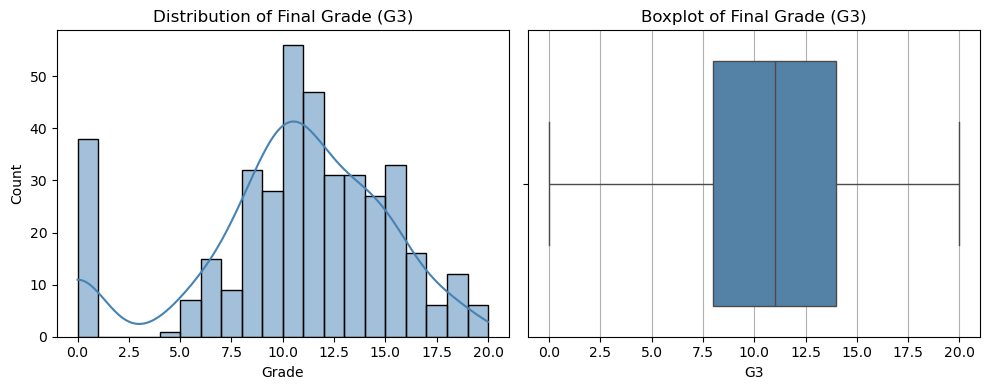

G3            1.000000
G2            0.904868
G1            0.801468
Medu          0.217147
Fedu          0.152457
studytime     0.097820
famrel        0.051363
absences      0.034247
freetime      0.011307
Walc         -0.051939
Dalc         -0.054660
health       -0.061335
traveltime   -0.117142
goout        -0.132791
age          -0.161579
failures     -0.360415
Name: G3, dtype: float64

In [26]:
# Distribution of fianl grade
fig, axes = plt.subplots(1,2, figsize = (10, 4))

sns.histplot(df['G3'], bins = 20, kde = True, edgecolor = 'k', color = 'steelblue', ax = axes[0])
axes[0].set_title("Distribution of Final Grade (G3)")
axes[0].set_xlabel('Grade')
axes[0].set_ylabel('Count')
plt.grid(True)

sns.boxplot(x = df['G3'], color = 'steelblue', ax = axes[1])
axes[1].set_title('Boxplot of Final Grade (G3)')

plt.tight_layout()
plt.show()

# Correlation of numeric features with  target
correlations = df[numeric_cols].corr()['G3'].sort_values(ascending = False)
correlations

# Creating Two Datasets for Regression and Classification

In [27]:
# Dataset 1: Regression 
# Remove the 38 zero students -- only keep active students
df_regression = df[df['G3'] > 0].copy()

print(f'Original Dataset: {df.shape[0]} students')
print(f'Regression Dataset: {df_regression.shape[0]} students')


Original Dataset: 395 students
Regression Dataset: 357 students


In [36]:
# Dataset 2: Classification
# Keep all 395 students -- but create a new binary target column
df_classification = df.copy()

# 0 = did not complete 
# 1 = completed the course 

df_classification['completed'] = (df['G3'] > 0).astype(int)

print(f"Classification dataset: {df_classification.shape[0]} students")
print(f"Target distribution:")
print(df_classification['completed'].value_counts())

Classification dataset: 395 students
Target distribution:
completed
1    357
0     38
Name: count, dtype: int64


# Understand What Each Dataset Will Be Used For

In [38]:
# Regression Dataset
# Question: Given an active student, what will their final grade be?
# Target column: G3 (a number -- 1 to 20)
# Students included: 357 active students only

print("="* 20  + "  Regression Datast " + "=" * 20)
display(df_regression[['G1', 'G2', 'G3']].describe().round(2))

====================  Regression Datast ====================


,G1,G2,G3
count,357.00,357.00,357.00
mean,11.27,11.36,11.52
std,3.24,3.15,3.23
min,3.00,5.00,4.00
25%,9.00,9.00,9.00
50%,11.00,11.00,11.00
75%,14.00,14.00,14.00
max,19.00,19.00,20.00


In [39]:
# Classification Dataset
# Question: Will this student complete the course or drop out?
# Target column: completed (0 to 1 -- binary)
# Students included: all 395 students

print("="* 20  + "  Classification Datast " + "=" * 20)
print(df_classification['completed'].value_counts())
print(f"Dropout rate: {(df_classification['completed'] == 0).mean()*100:.1f}%")

====================  Classification Datast ====================
completed
1    357
0     38
Name: count, dtype: int64
Dropout rate: 9.6%


# Save Both Dataset Separately

In [41]:
# Save them so you never have to rebuild them again
df_regression.to_csv('student_regression.csv', index = False)
df_classification.to_csv('student_classification.csv', index = False)

print("Both Dataset Saved Successfully.")

Both Dataset Saved Successfully.
